# Modelo de Minería — Predicción de Recontacto (Árbol de Decisión)

**Objetivo:** ya sabemos, por el KPI 1, que la Tasa de Recontacto en 7 Días (TR7D) es alta (~40%).
Este notebook va un paso más allá: entrena un **árbol de decisión** para intentar *explicar* qué
combinación de variables hace que una interacción termine en recontacto, y confirmar o descartar
la hipótesis que dejamos anotada en `01_kpis_recontacto_duracion.ipynb` (Red social + duración corta → más recontacto).

**Variable de resultado (target):** `recontacto_7_dias` (1 = recontactó, 0 = no recontactó).

**Variables explicativas (features):** canal, motivo de contacto, cola de servicio, turno, tipo de
usuario, espera_seg, duracion_seg, transferencias, casos_previos_30d, si fue fin de semana.

No se usa `id_interaccion` ni `fecha_contacto` como variable explicativa: son identificadores/tiempo
crudo, no aportan patrón generalizable (usar la fecha exacta produciría un modelo que "memoriza"
en vez de aprender un patrón).

In [17]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from cargar_datos import cargar_dataset_modelo

df = cargar_dataset_modelo()
df.head()

📊 CARGANDO DATASET — Modelo de Recontacto (todas las variables)


/home/abemilek/Documentos/workspace/servicio-ciudadano-mineria/proyecto/notebooks/../src/database.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn, params=params) if params else pd.read_sql_query(query, conn)



📏 Dimensiones: 9,830 filas × 12 columnas

🎯 Distribución de la variable de resultado (recontacto_7_dias):
recontacto_7_dias
0    5863
1    3967
Name: count, dtype: int64


,id_interaccion,canal,motivo_contacto,cola_servicio,turno,tipo_usuario,espera_seg,duracion_seg,transferencias,casos_previos_30d,es_fin_semana,recontacto_7_dias
0,C15-00001,Chat,Consulta,Soporte,AM,Nuevo,320,1241,1,0,True,0
1,C15-00002,Correo,Consulta,Facturación,Nocturno,Recurrente,301,743,2,1,False,0
2,C15-00003,Correo,Solicitud,Reclamos,PM,Recurrente,438,1101,0,5,False,0
3,C15-00005,Chat,Solicitud,Soporte,AM,Nuevo,45,1173,0,5,False,0
4,C15-00006,Chat,Consulta,Información,PM,Recurrente,298,1086,0,0,False,1


## 1. Preparar los datos

Los modelos de scikit-learn no entienden texto (`"Chat"`, `"Falla"`, etc.), solo números.
Convertimos cada variable categórica en columnas 0/1 con `pd.get_dummies` (una técnica llamada
*one-hot encoding*). No es que los datos "no sirvan" en texto — es que hay que traducirlos a un
formato que el algoritmo pueda procesar matemáticamente, tal como se explicó en clase.

In [18]:
columnas_categoricas = ['canal', 'motivo_contacto', 'cola_servicio', 'turno', 'tipo_usuario']
columnas_numericas = ['espera_seg', 'duracion_seg', 'transferencias', 'casos_previos_30d', 'es_fin_semana']

X = pd.get_dummies(df[columnas_categoricas + columnas_numericas], columns=columnas_categoricas)
y = df['recontacto_7_dias'].astype(int)

print(f"Features finales: {X.shape[1]} columnas (tras el one-hot encoding)")
print(f"Distribución del target:\n{y.value_counts(normalize=True).round(3) * 100}")
X.head()

Features finales: 28 columnas (tras el one-hot encoding)
Distribución del target:
recontacto_7_dias
0    59.6
1    40.4
Name: proportion, dtype: float64


,espera_seg,duracion_seg,transferencias,casos_previos_30d,es_fin_semana,canal_(sin dato),canal_Chat,canal_Correo,canal_Red social,canal_Teléfono,...,cola_servicio_Soporte,cola_servicio_Trámites,turno_AM,turno_Fin de semana,turno_Nocturno,turno_PM,tipo_usuario_Adulto mayor,tipo_usuario_Empresa,tipo_usuario_Nuevo,tipo_usuario_Recurrente
0,320,1241,1,0,True,False,True,False,False,False,...,True,False,True,False,False,False,False,False,True,False
1,301,743,2,1,False,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,438,1101,0,5,False,False,False,True,False,False,...,False,False,False,False,False,True,False,False,False,True
3,45,1173,0,5,False,False,True,False,False,False,...,True,False,True,False,False,False,False,False,True,False
4,298,1086,0,0,False,False,True,False,False,False,...,False,False,False,False,False,True,False,False,False,True


## 2. Separar en entrenamiento y prueba

Guardamos una parte de los datos (25%) que el modelo **nunca ve durante el entrenamiento**, para
evaluar honestamente qué tan bien generaliza — si lo evaluáramos con los mismos datos con los que
aprendió, no sabríamos si de verdad "entendió" el patrón o solo lo memorizó.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f"Entrenamiento: {X_train.shape[0]} filas | Prueba: {X_test.shape[0]} filas")

Entrenamiento: 7372 filas | Prueba: 2458 filas


## 3. Entrenar el árbol de decisión

Usamos `max_depth=5`: es la profundidad que sugiere el profesor, y sigue siendo interpretable
a simple vista. Limitamos la profundidad a propósito porque un árbol muy profundo memoriza el
ruido de los datos (sobreajuste / *overfitting*) en vez de aprender un patrón general — y además
sería ilegible para explicárselo a un gerente. En la sección 6 comparamos varias profundidades
para justificar esta elección con datos, en vez de repetirla de memoria.

In [20]:
modelo = DecisionTreeClassifier(max_depth=5, random_state=42, class_weight='balanced')
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)
print(f"Exactitud (accuracy) en datos de prueba: {accuracy_score(y_test, y_pred):.2%}")
print()
print(classification_report(y_test, y_pred, target_names=['No recontacta (0)', 'Recontacta (1)']))

Exactitud (accuracy) en datos de prueba: 72.74%

                   precision    recall  f1-score   support

No recontacta (0)       0.78      0.76      0.77      1466
   Recontacta (1)       0.66      0.69      0.67       992

         accuracy                           0.73      2458
        macro avg       0.72      0.72      0.72      2458
     weighted avg       0.73      0.73      0.73      2458



**Cómo leer esto:** la exactitud (*accuracy*) sola no basta —un modelo que siempre dijera
"no recontacta" ya acertaría bastante seguido solo porque esa clase es mayoría. Por eso miramos
también *precision* y *recall* de la clase "Recontacta (1)": nos interesa sobre todo qué tan bien
detecta los casos que **sí** van a recontactar, porque son los que queremos prevenir.

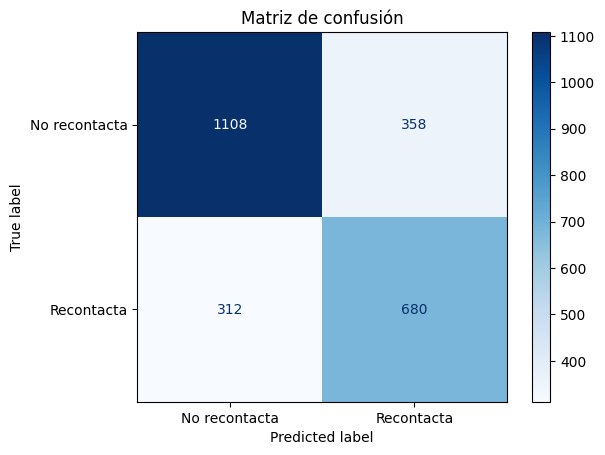

In [21]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['No recontacta', 'Recontacta'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Matriz de confusión')
plt.show()

## 4. ¿Qué variables pesan más? (importancia de variables)

Esto le responde directamente al gerente la pregunta *"¿en qué me tengo que fijar?"* — no todas las
variables aportan lo mismo para predecir el recontacto.

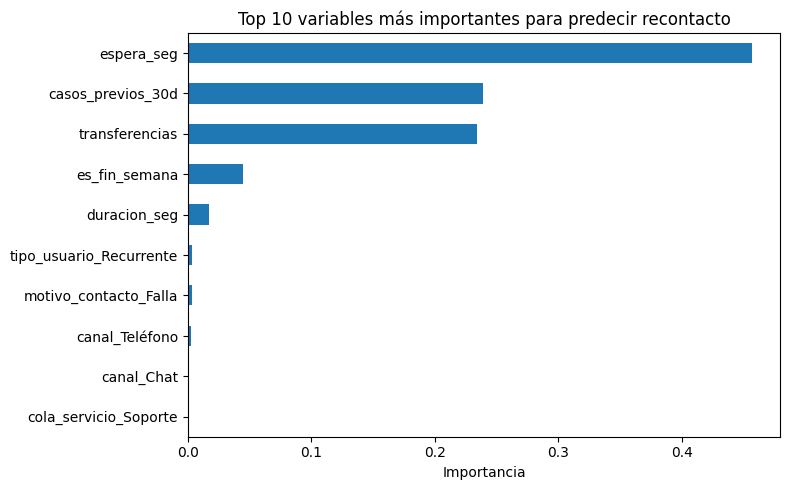

espera_seg                 0.456577
casos_previos_30d          0.238668
transferencias             0.233940
es_fin_semana              0.044840
duracion_seg               0.016820
tipo_usuario_Recurrente    0.003502
motivo_contacto_Falla      0.003130
canal_Teléfono             0.002524
canal_Chat                 0.000000
cola_servicio_Soporte      0.000000
dtype: float64

In [22]:
importancias = pd.Series(modelo.feature_importances_, index=X.columns).sort_values(ascending=False)
top10 = importancias.head(10)

top10.plot(kind='barh', figsize=(8, 5))
plt.gca().invert_yaxis()
plt.title('Top 10 variables más importantes para predecir recontacto')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

top10

## 5. Ver el árbol completo

Cada caja muestra: la condición que evalúa, cuántos casos caen ahí (`samples`), y cómo se reparten
entre las dos clases (`value = [no_recontacta, recontacta]`). Seguir el camino de la raíz hasta una
hoja es literalmente la "regla" que encontró el modelo.

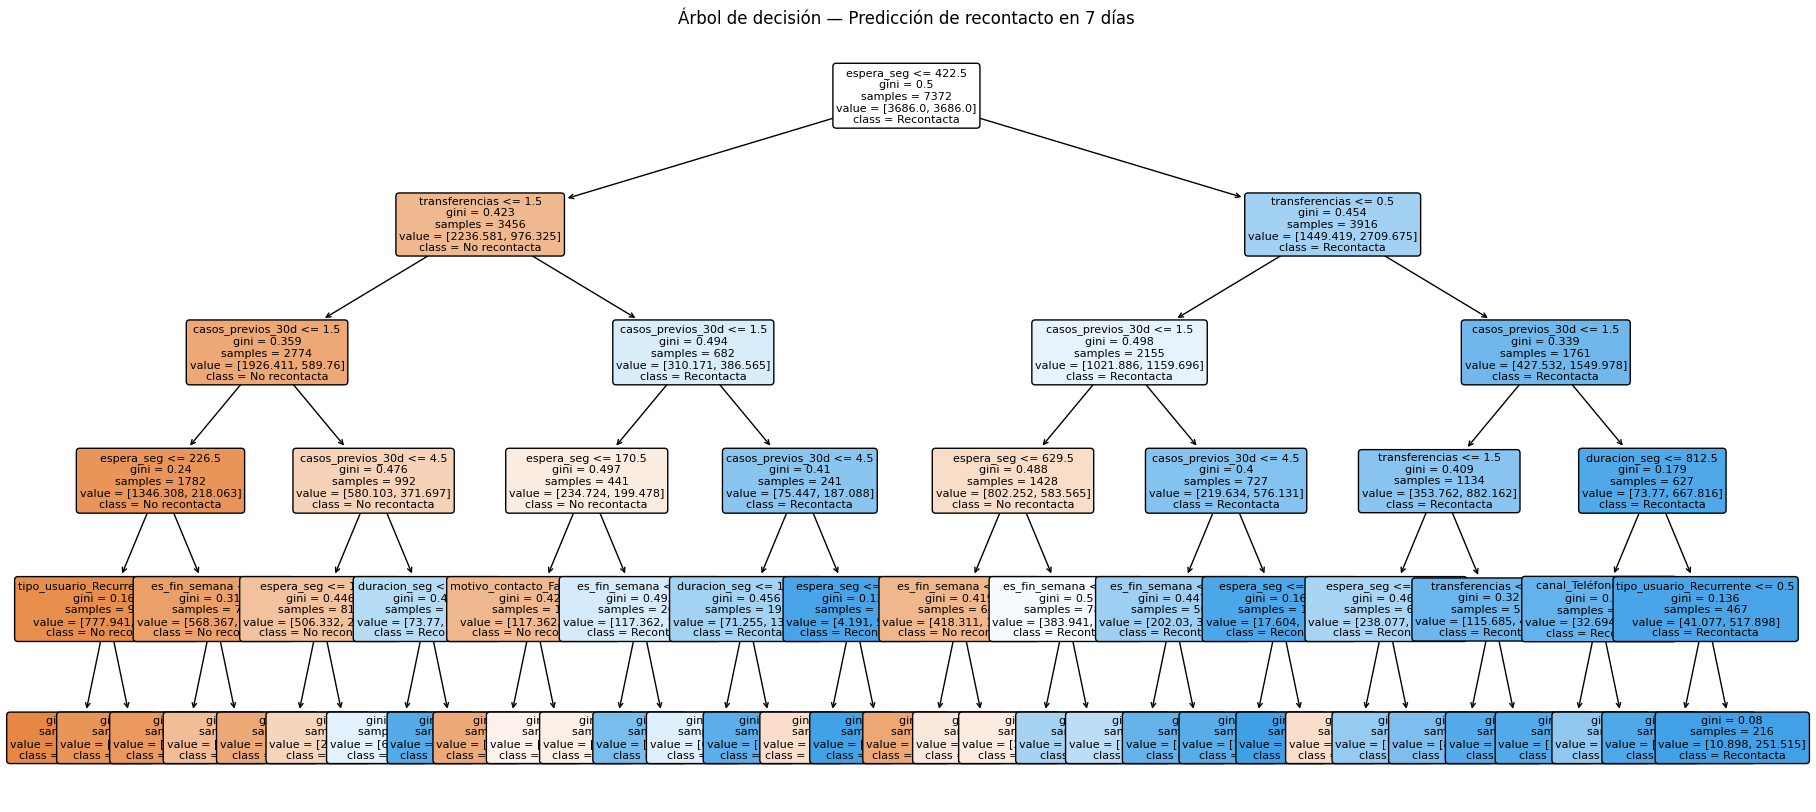

In [23]:
plt.figure(figsize=(22, 10))
plot_tree(
    modelo,
    feature_names=X.columns,
    class_names=['No recontacta', 'Recontacta'],
    filled=True,
    rounded=True,
    fontsize=8,
)
plt.title('Árbol de decisión — Predicción de recontacto en 7 días')
plt.show()

## 6. ¿El modelo mejora respecto a no hacer nada? — Línea base y variantes

Antes de sacar conclusiones hay que responder algo incómodo pero necesario: **¿el árbol le gana a
la opción más tonta posible?** La opción más tonta es predecir siempre la clase que más se repite
("no recontacta"), sin mirar ningún dato. Si el árbol no le gana ni a eso, el árbol no está
aportando nada todavía.

También comparamos variantes: con y sin `class_weight='balanced'` (ese parámetro le dice al árbol
que le dé la misma importancia a acertar en "recontacta" que en "no recontacta", aunque haya menos
casos de recontacto — a cambio, suele bajar la exactitud total), y con distintas profundidades
(`max_depth`) para ver si un árbol más simple o más complejo cambia el resultado.

In [24]:
from sklearn.metrics import recall_score, precision_score

resultados = []

# Línea base: predecir siempre la clase mayoritaria del set de entrenamiento, sin mirar ningún dato
clase_mayoritaria = y_train.mode()[0]
pred_base = pd.Series(clase_mayoritaria, index=y_test.index)
resultados.append({
    'modelo': 'Línea base (siempre predice la clase mayoritaria)',
    'accuracy': accuracy_score(y_test, pred_base),
    'recall_recontacta': recall_score(y_test, pred_base, pos_label=1, zero_division=0),
    'precision_recontacta': precision_score(y_test, pred_base, pos_label=1, zero_division=0),
})

# Variantes del árbol: profundidad y balanceo de clases
configuraciones = [
    ('Árbol depth=5, balanceado (el de arriba)', 5, 'balanced'),
    ('Árbol depth=5, SIN balancear',             5, None),
    ('Árbol depth=3, balanceado',                3, 'balanced'),
    ('Árbol depth=4, balanceado',                4, 'balanced'),
    ('Árbol depth=4, SIN balancear',             4, None),
    ('Árbol depth=6, balanceado',                6, 'balanced'),
    ('Árbol depth=6, SIN balancear',             6, None),
    ('Árbol depth=7, SIN balancear',             7, None),
]

for nombre, profundidad, peso in configuraciones:
    m = DecisionTreeClassifier(max_depth=profundidad, random_state=42, class_weight=peso)
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    resultados.append({
        'modelo': nombre,
        'accuracy': accuracy_score(y_test, pred),
        'recall_recontacta': recall_score(y_test, pred, pos_label=1, zero_division=0),
        'precision_recontacta': precision_score(y_test, pred, pos_label=1, zero_division=0),
    })

tabla_comparacion = pd.DataFrame(resultados).set_index('modelo').round(3)
tabla_comparacion

,accuracy,recall_recontacta,precision_recontacta
modelo,,,
Línea base (siempre predice la clase mayoritaria),0.596,0.000,0.000
"Árbol depth=5, balanceado (el de arriba)",0.727,0.685,0.655
"Árbol depth=5, SIN balancear",0.725,0.675,0.654
"Árbol depth=3, balanceado",0.718,0.604,0.666
"Árbol depth=4, balanceado",0.688,0.781,0.585
"Árbol depth=4, SIN balancear",0.714,0.601,0.661
"Árbol depth=6, balanceado",0.715,0.701,0.632
"Árbol depth=6, SIN balancear",0.729,0.656,0.666
"Árbol depth=7, SIN balancear",0.742,0.594,0.718


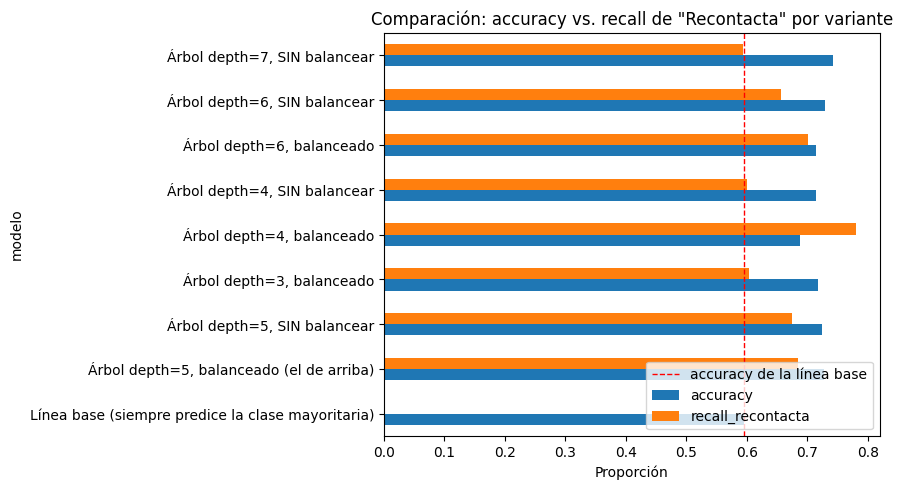

In [25]:
tabla_comparacion[['accuracy', 'recall_recontacta']].plot(
    kind='barh', figsize=(9, 5)
)
plt.axvline(x=tabla_comparacion.loc['Línea base (siempre predice la clase mayoritaria)', 'accuracy'],
            color='red', linestyle='--', linewidth=1, label='accuracy de la línea base')
plt.legend(loc='lower right')
plt.xlabel('Proporción')
plt.title('Comparación: accuracy vs. recall de "Recontacta" por variante')
plt.tight_layout()
plt.show()

**Cómo leer esta tabla:** no existe una variante "ganadora" en todo — hay un trade-off:

- Si el objetivo es **acertar en general**, importa más la columna `accuracy` — ahí compite la
  línea base (que no usa ningún dato) contra los árboles.
- Si el objetivo del negocio es **no dejar pasar casos que van a recontactar** (que es justo lo que
  dijo el gerente en el audio de auditoría: "que no lo llames tú a preguntar, que no tenga que
  volver a contactar"), entonces importa más `recall_recontacta` — ahí el balanceo ayuda, aunque
  cueste exactitud general.

Si en tu tabla la línea base sigue ganando en `accuracy` a todas las variantes, eso confirma que —
con este dataset sintético y estas variables— el árbol todavía no encontró un patrón lo bastante
fuerte. No es un callejón sin salida: es la razón por la que el paso 5 del proyecto (cuando llegue
el dataset real) importa tanto — un patrón que no existe en datos ficticios calibrados solo por
promedios puede sí existir en el comportamiento real de la gente.

## 7. Conclusión (a completar por el equipo)

Con estos resultados, el equipo debe responder por escrito (para el informe / defensa):

- Según la tabla de la sección 6: ¿alguna variante le ganó de verdad a la línea base? ¿En
  `accuracy`, en `recall_recontacta`, o en ninguna de las dos?
- Según la importancia de variables (sección 4): ¿se confirma la hipótesis Red social + duración
  corta → más recontacto que quedó anotada en el notebook de KPIs, o el árbol encontró otra cosa
  (por ejemplo, duración/transferencias/espera en general, sin importar tanto el canal)?
- ¿Qué acción concreta sugeriría el equipo a Operaciones/Calidad a partir de la regla más
  importante del árbol (la que está más arriba, cerca de la raíz)?
- Si ninguna variante superó la línea base: ¿qué se probaría después? (más variables, más datos,
  otro algoritmo, o esperar el dataset real).

*Nota: como el dataset sigue siendo el sintético (`generar_semilla.py`), estas conclusiones son
un ensayo del pipeline completo — quedan sujetas a repetirse cuando llegue el dataset real
`C15_CallCenter`.